# Class Imbalance Handling

## Project: Financial Fraud Detection & Risk Intelligence System

The target variable is `Fraudulent`:

- 0: Non-fraudulent transaction
- 1: Fraudulent transaction

The dataset contains an unequal distribution between
non-fraudulent and fraudulent transactions.

This notebook evaluates suitable imbalance-handling
strategies and compares their impact on fraud detection.

Strategies considered:

1. Unweighted baseline
2. Class-weighted learning
3. SMOTE-based oversampling
4. Probability threshold adjustment

The final strategy will be assessed using fraud-focused
evaluation metrics and business considerations.

In [4]:
import pandas as pd
import numpy as np

# Load raw dataset
df = pd.read_csv(
    "../data/raw/financial_fraud_detection_dataset.csv"
)

# Convert transaction date
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="%d-%m-%Y %H:%M"
)

# Create a feature-engineering copy
df_fe = df.copy()

# Time-based features
df_fe["Transaction_Hour"] = (
    df_fe["Transaction_Date"].dt.hour
)

df_fe["Transaction_DayOfWeek"] = (
    df_fe["Transaction_Date"].dt.dayofweek
)

df_fe["Transaction_Month"] = (
    df_fe["Transaction_Date"].dt.month
)

df_fe["Transaction_Day"] = (
    df_fe["Transaction_Date"].dt.day
)

df_fe["Is_Weekend"] = (
    df_fe["Transaction_DayOfWeek"] >= 5
).astype(int)

# Amount-based features
df_fe["Amount_to_Average_Ratio"] = (
    df_fe["Transaction_Amount"] /
    df_fe["Average_Spend"]
)

df_fe["Amount_vs_Average_Difference"] = (
    df_fe["Transaction_Amount"] -
    df_fe["Average_Spend"]
)

# Previous transactions band
df_fe["Previous_Transactions_Band"] = pd.cut(
    df_fe["Previous_Transactions"],
    bins=[0, 25, 50, 100, 150, 200],
    labels=[
        "1-25",
        "26-50",
        "51-100",
        "101-150",
        "151-200"
    ],
    include_lowest=True
)

# Log-transformed ratio
df_fe["Log_Amount_to_Average_Ratio"] = np.log1p(
    df_fe["Amount_to_Average_Ratio"]
)

# Check the result
print("df_fe shape:", df_fe.shape)
print(df_fe.columns.tolist())

df_fe shape: (5000, 23)
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_Month', 'Transaction_Day', 'Is_Weekend', 'Amount_to_Average_Ratio', 'Amount_vs_Average_Difference', 'Previous_Transactions_Band', 'Log_Amount_to_Average_Ratio']


In [5]:
import pandas as pd

target_distribution = (df_fe["Fraudulent"].value_counts().sort_index())
target_percentage = (df_fe["Fraudulent"].value_counts(normalize=True).sort_index().mul(100))

imbalance_summary = pd.DataFrame({"Transaction_Count": target_distribution,"Percentage": target_percentage.round(2)})
imbalance_summary

,Transaction_Count,Percentage
Fraudulent,,
0,4518,90.36
1,482,9.64


In [6]:
# Define numerical features
numeric_features = [
    "Transaction_Amount",
    "Is_International",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days",
    "Transaction_Hour",
    "Transaction_DayOfWeek",
    "Transaction_Month",
    "Transaction_Day",
    "Is_Weekend",
    "Amount_to_Average_Ratio",
    "Amount_vs_Average_Difference",
    "Log_Amount_to_Average_Ratio"
]

# Define categorical features
categorical_features = ["Merchant_Category", "Payment_Method","Device_Type", "Location", "Previous_Transactions_Band"]

# Combine all model features
feature_columns = numeric_features + categorical_features

# Define input features (X) and target (y)
X = df_fe[feature_columns]

y = df_fe["Fraudulent"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 18)
y shape: (5000,)


In [7]:
#Create the train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 18)
X_test shape: (1000, 18)
y_train shape: (4000,)
y_test shape: (1000,)


In [8]:
##Verify class distribution
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

print("\nTesting target percentage:")
print(
    y_test.value_counts(normalize=True).mul(100).round(2)
)

Training target distribution:
Fraudulent
0    3614
1     386
Name: count, dtype: int64

Testing target distribution:
Fraudulent
0    904
1     96
Name: count, dtype: int64

Training target percentage:
Fraudulent
0    90.35
1     9.65
Name: proportion, dtype: float64

Testing target percentage:
Fraudulent
0    90.4
1     9.6
Name: proportion, dtype: float64


Dataset         Non-Fraud (0)      Fraud (1)         Total

Training         3,614              386              4,000
Testing            904               96              1,000
Total            4,518              482              5,000

In [9]:
# Display the numerical features
print("Numeric features:")
print(numeric_features)

# Display the categorical features
print("\nCategorical features:")
print(categorical_features)

# Display the total number of features
print("\nTotal features:", len(feature_columns))
print(len(feature_columns))

Numeric features:
['Transaction_Amount', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_Month', 'Transaction_Day', 'Is_Weekend', 'Amount_to_Average_Ratio', 'Amount_vs_Average_Difference', 'Log_Amount_to_Average_Ratio']

Categorical features:
['Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Previous_Transactions_Band']

Total features: 18
18


In [10]:
#Create the preprocessing pipeline
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create the numerical preprocessing pipeline
numeric_transformer = StandardScaler()

# Create the categorical preprocessing pipeline
categorical_transformer = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        # Apply scaling to numerical features
        ("num", numeric_transformer, numeric_features),

        # Apply one-hot encoding to categorical features
        ("cat", categorical_transformer, categorical_features)])

# Display confirmation
print("Preprocessor created successfully!")


Preprocessor created successfully!


In [11]:
#Train a class-weighted Logistic Regression model

# Import the required machine learning tools
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the class-weighted Logistic Regression pipeline
weighted_logistic_pipeline = Pipeline(
    steps=[
        # Apply preprocessing to the input features
        ("preprocessor", preprocessor),

        # Train Logistic Regression with balanced class weights
        ("classifier", LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42))])

# Train the model using only the training data
weighted_logistic_pipeline.fit(X_train,y_train)

# Display confirmation
print("Class-weighted Logistic Regression trained successfully!")

Class-weighted Logistic Regression trained successfully!


In [12]:
# Generate predicted class labels for the test set
weighted_y_pred = weighted_logistic_pipeline.predict(X_test)

# Generate fraud probabilities for the test set
weighted_y_prob = weighted_logistic_pipeline.predict_proba(X_test)[:, 1]

# Display the first 10 predictions
print("First 10 predicted classes:")
print(weighted_y_pred[:10])

# Display the first 10 fraud probabilities
print("\nFirst 10 fraud probabilities:")
print(weighted_y_prob[:10])

First 10 predicted classes:
[1 0 0 0 0 0 1 1 0 0]

First 10 fraud probabilities:
[0.61942914 0.42544659 0.24698667 0.08739056 0.05135319 0.08198795
 0.54281573 0.77674653 0.42847459 0.08840602]


In [13]:
# Evaluate the weighted model
# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Display the classification report
print("Classification Report:")
print(classification_report(y_test,weighted_y_pred,zero_division=0))

# Calculate the confusion matrix
weighted_cm = confusion_matrix(y_test,weighted_y_pred)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(weighted_cm)

# Calculate fraud precision
weighted_precision = precision_score(y_test,weighted_y_pred,zero_division=0)

# Calculate fraud recall
weighted_recall = recall_score(y_test,weighted_y_pred,zero_division=0)

# Calculate fraud F1-score
weighted_f1 = f1_score(y_test,weighted_y_pred,zero_division=0)

# Calculate ROC-AUC
weighted_roc_auc = roc_auc_score(y_test,weighted_y_prob)

# Calculate Average Precision (PR-AUC approximation)
weighted_average_precision = average_precision_score(y_test,weighted_y_prob)

# Display the evaluation metrics
print("\nEvaluation Metrics:")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall: {weighted_recall:.4f}")
print(f"F1-Score: {weighted_f1:.4f}")
print(f"ROC-AUC: {weighted_roc_auc:.4f}")
print(f"Average Precision: " 
      f"{weighted_average_precision:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.83       904
           1       0.22      0.73      0.34        96

    accuracy                           0.72      1000
   macro avg       0.59      0.73      0.58      1000
weighted avg       0.89      0.72      0.78      1000


Confusion Matrix:
[[653 251]
 [ 26  70]]

Evaluation Metrics:
Precision: 0.2181
Recall: 0.7292
F1-Score: 0.3357
ROC-AUC: 0.7532
Average Precision: 0.2571


                    Predicted Non-Fraud            Predicted Fraud
Actual Non-Fraud    653 (TN)                       251 (FP)
Actual Fraud        26 (FN)                        70 (TP)


Metric                 Class-Weighted Logistic Regression  
Accuracy               72.0%
Fraud precision        21.81%
Fraud recall           72.92%
Fraud F1-score         33.57%
ROC-AUC                0.7532
False positives        251
False negatives        26

In [14]:
# Import pandas
import pandas as pd

# Create a comparison table for both Logistic Regression models
imbalance_comparison = pd.DataFrame({"Model": ["Original Logistic Regression","Class-Weighted Logistic Regression"],

    # Model accuracy
    "Accuracy": [0.896,0.720],

    # Fraud precision
    "Fraud_Precision": [0.3571,weighted_precision],

    # Fraud recall
    "Fraud_Recall": [0.1042,weighted_recall],

    # Fraud F1-score
    "Fraud_F1": [0.1613,weighted_f1],

    # ROC-AUC
    "ROC_AUC": [0.7454,weighted_roc_auc],

    # Average Precision
    "Average_Precision": [None,weighted_average_precision],

    # False positives
    "False_Positives": [18,weighted_cm[0, 1]],

    # False negatives
    "False_Negatives": [86,weighted_cm[1, 0]]})

# Display the comparison table
imbalance_comparison

,Model,Accuracy,Fraud_Precision,Fraud_Recall,Fraud_F1,ROC_AUC,Average_Precision,False_Positives,False_Negatives
0,Original Logistic Regression,0.896,0.357100,0.104200,0.161300,0.745400,NaN,18,86
1,Class-Weighted Logistic Regression,0.720,0.218069,0.729167,0.335731,0.753169,0.257077,251,26


# Important observations

1. Fraud recall increased: The class-weighted model detects 70 of the 96 fraudulent transactions in the test set, compared with 10 detected by the original model.
2. False positives increased: The weighted model incorrectly flags 251 legitimate transactions, compared with 18 for the original model.
3. ROC-AUC changed only slightly: The ROC-AUC values are 0.7454 and 0.7532. This indicates that changing the class weights did not produce a dramatic difference in ranking performance on this test split.
4. Average Precision is missing for the original model: The NaN value is present because we inserted None for the original model's Average Precision. We should calculate it rather than leave it blank.

In [15]:
# Create the original Logistic Regression pipeline
# Import the required machine learning tools
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the original Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        # Apply the preprocessing transformations
        ("preprocessor", preprocessor),

        # Train Logistic Regression without class weighting
        ("classifier",LogisticRegression(max_iter=1000,random_state=42))])

# Train the original model using the training data
logistic_pipeline.fit(X_train,y_train)

# Display a confirmation message
print("Original Logistic Regression trained successfully!")

Original Logistic Regression trained successfully!


In [16]:
# Generate fraud probabilities for the test dataset
original_y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

# Generate predicted classes using the default threshold
original_y_pred = logistic_pipeline.predict(X_test)

# Display the first 10 fraud probabilities
print("First 10 original fraud probabilities:")
print(original_y_prob[:10])

First 10 original fraud probabilities:
[0.14319726 0.09003243 0.03335306 0.01223235 0.00971553 0.01146357
 0.12977037 0.19457263 0.08483205 0.01026989]


In [17]:
# Import the Average Precision metric
from sklearn.metrics import average_precision_score

# Calculate Average Precision for the original model
original_average_precision = average_precision_score(y_test,original_y_prob)

# Display the result
print(f"Original Average Precision: "
      f"{original_average_precision:.4f}")

Original Average Precision: 0.2587


In [18]:
# Create the updated model comparison table
imbalance_comparison = pd.DataFrame({"Model": ["Original Logistic Regression", "Class-Weighted Logistic Regression"],

    # Model accuracy
    "Accuracy": [0.896,0.720],

    # Fraud precision
    "Fraud_Precision": [0.3571,weighted_precision],

    # Fraud recall
    "Fraud_Recall": [0.1042,weighted_recall],

    # Fraud F1-score
    "Fraud_F1": [0.1613,weighted_f1],

    # ROC-AUC
    "ROC_AUC": [0.7454,weighted_roc_auc],

    # Average Precision
    "Average_Precision": [original_average_precision,weighted_average_precision],

    # False positives
    "False_Positives": [18,weighted_cm[0, 1]],

    # False negatives
    "False_Negatives": [86,weighted_cm[1, 0]]})

# Display the updated comparison table
imbalance_comparison

,Model,Accuracy,Fraud_Precision,Fraud_Recall,Fraud_F1,ROC_AUC,Average_Precision,False_Positives,False_Negatives
0,Original Logistic Regression,0.896,0.357100,0.104200,0.161300,0.745400,0.258707,18,86
1,Class-Weighted Logistic Regression,0.720,0.218069,0.729167,0.335731,0.753169,0.257077,251,26


In [19]:
# Import the required evaluation metrics
from sklearn.metrics import (precision_score,recall_score,f1_score,confusion_matrix)

# Define the thresholds for our experiment
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

# Create an empty list to store threshold results
weighted_threshold_results = []

# Evaluate each threshold
for threshold in thresholds:

    # Convert probabilities into binary predictions
    threshold_predictions = (weighted_y_prob >= threshold).astype(int)

    # Calculate precision
    precision = precision_score(y_test,threshold_predictions,zero_division=0)

    # Calculate recall
    recall = recall_score(y_test,threshold_predictions,zero_division=0)

    # Calculate F1-score
    f1 = f1_score(y_test,threshold_predictions,zero_division=0)

    # Calculate the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test,threshold_predictions).ravel()

    # Store the results for the current threshold
    weighted_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

# Convert the results into a DataFrame
weighted_threshold_results_df = pd.DataFrame(weighted_threshold_results)

# Display the threshold comparison
weighted_threshold_results_df

,Threshold,Precision,Recall,F1_Score,True_Negatives,False_Positives,False_Negatives,True_Positives
0,0.3,0.150476,0.822917,0.254428,458,446,17,79
1,0.4,0.182898,0.802083,0.297872,560,344,19,77
2,0.5,0.218069,0.729167,0.335731,653,251,26,70
3,0.6,0.240909,0.552083,0.335443,737,167,43,53
4,0.7,0.286822,0.385417,0.328889,812,92,59,37


Here I want to understand how changing the threshold affects:

Fraud detection (recall).
Alert accuracy (precision).
False positives.
False negatives.
F1-score.

Observation 1: Lower thresholds increase recall. At a threshold of 0.3:
Fraud recall: 82.29%.
Fraudulent transactions detected: 79 out of 96.
False positives: 446.
The model catches more fraud but flags many legitimate transactions.

Observation 2: Higher thresholds reduce false positives. At a threshold of 0.7:
Fraud recall: 38.54%.
Fraudulent transactions detected: 37 out of 96.
False positives: 92.
The model generates fewer false alerts, but it misses more fraudulent transactions.

Observation 3: F1-score changes across thresholds
The highest F1-score in your tested results is approximately 33.57% at threshold 0.5, closely followed by approximately 33.54% at 0.6. The difference is very small, so we should not treat it as conclusive evidence that one threshold is superior. Further validation is needed.

Threshold Analysis: Thresholds from 0.3 to 0.7 were evaluated using the class-weighted Logistic Regression model. Lower thresholds increased fraud recall but also increased false positives. Higher thresholds reduced false positives while lowering fraud recall. The results demonstrate the trade-off between fraud detection sensitivity and alert volume. Additional validation is required before selecting the operating threshold.

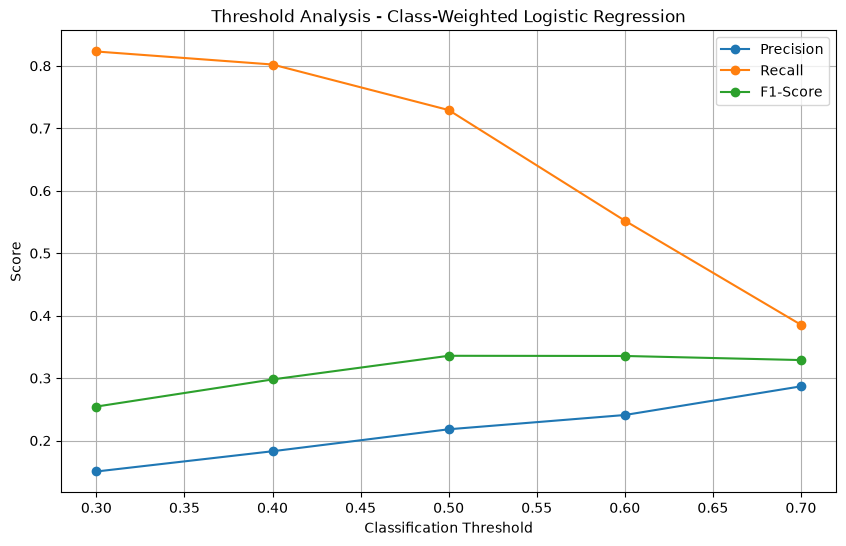

In [20]:
# Import the plotting library
import matplotlib.pyplot as plt

# Create a figure for the metric comparison
plt.figure(figsize=(10, 6))

# Plot precision against the threshold
plt.plot(
    weighted_threshold_results_df["Threshold"],
    weighted_threshold_results_df["Precision"],
    marker="o",
    label="Precision")

# Plot recall against the threshold
plt.plot(
    weighted_threshold_results_df["Threshold"],
    weighted_threshold_results_df["Recall"],
    marker="o",
    label="Recall")

# Plot F1-score against the threshold
plt.plot(
    weighted_threshold_results_df["Threshold"],
    weighted_threshold_results_df["F1_Score"],
    marker="o",
    label="F1-Score")

# Add a chart title
plt.title("Threshold Analysis - Class-Weighted Logistic Regression")

# Add the x-axis label
plt.xlabel("Classification Threshold")

# Add the y-axis label
plt.ylabel("Score")

# Display the legend
plt.legend()

# Display the grid
plt.grid(True)

# Display the chart
plt.show()

In [21]:
# Import Matplotlib's plotting module
import matplotlib.pyplot as plt

# Confirm that the import was successful
print("Matplotlib imported successfully!")

Matplotlib imported successfully!


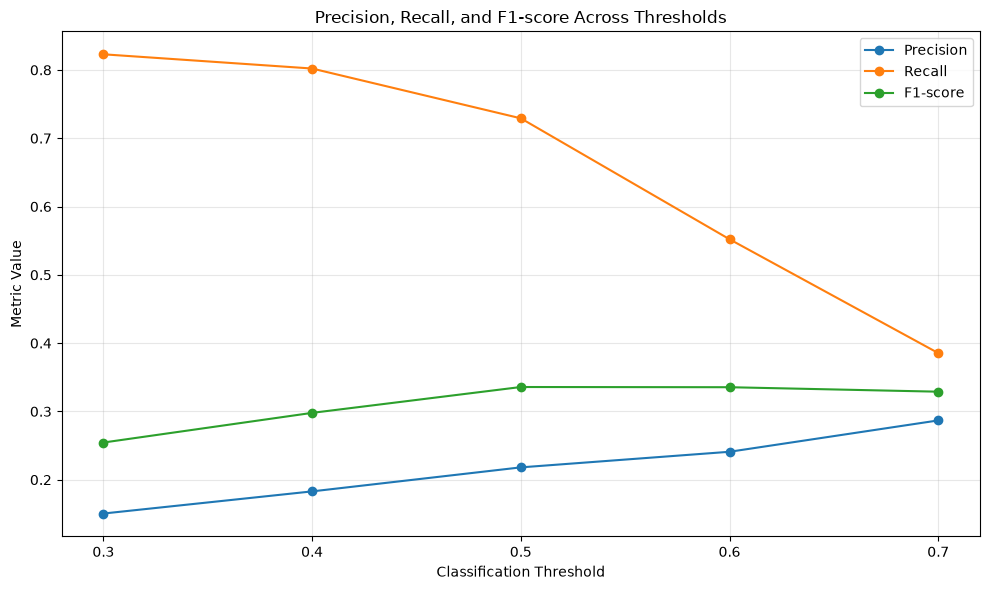

In [22]:
# Import the required library
import matplotlib.pyplot as plt

# Store the threshold values tested during our analysis
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

# Store the previously calculated precision values
precision_values = [0.150476, 0.182898, 0.218069, 0.240909, 0.286822]

# Store the previously calculated recall values
recall_values = [0.822917, 0.802083, 0.729167, 0.552083, 0.385417]

# Store the previously calculated F1-score values
f1_values = [0.254428, 0.297872, 0.335731, 0.335443, 0.328889]

# Create the figure
plt.figure(figsize=(10, 6))

# Plot precision against the classification threshold
plt.plot(thresholds,precision_values,marker="o",label="Precision")

# Plot recall against the classification threshold
plt.plot(thresholds,recall_values,marker="o",label="Recall")

# Plot F1-score against the classification threshold
plt.plot(thresholds,f1_values,marker="o",label="F1-score")

# Add the chart title and axis labels
plt.title("Precision, Recall, and F1-score Across Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")

# Display the threshold values clearly on the x-axis
plt.xticks(thresholds)

# Add a grid to make the values easier to compare
plt.grid(True, alpha=0.3)

# Display the legend
plt.legend()

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the chart
plt.show()